In [1]:
import pickle
import numpy as np
import pandas as pd
import os.path as op
import itertools as it
from pathlib import Path
import matplotlib.pylab as plt
from lameg.util import get_files
import nibabel as nib
from scipy.spatial.distance import euclidean
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import Normalize
from matplotlib.patches import Patch
from matplotlib.gridspec import GridSpec

In [2]:
plt.rcParams.update({
    'font.size': 16,
    'axes.spines.right': False,
    'axes.spines.top': False,
    'xtick.major.size': 6,
    'xtick.major.width': 1.2,
    'ytick.major.size': 6,
    'ytick.major.width': 1.2,
    'legend.frameon': False,
    'legend.handletextpad': 0.1,
    'svg.fonttype': 'none',
    'text.usetex': False
})

In [3]:
def add_subplot_label(ax, label, x=-.21, y=1.225):
    ax.text(x, y, label,  # Adjust left of y-axis
            transform=ax.transAxes,
            fontsize=26, va='top', ha='right')


In [4]:
n_layers = 11
layers = np.arange(n_layers)
vx_loc, vx_adj, surf_norm = nib.load(Path("/home/common/bonaiuto/cued_action_meg/derivatives/processed/sub-001/surf/multilayer.11.ds.link_vector.fixed.gii")).agg_data()
layers_loc = np.array(np.split(vx_loc, n_layers, axis=0))
cortical_thickness = np.array([euclidean(layers_loc[0, i, :], layers_loc[-1, i, :]) for i in range(layers_loc.shape[1])])

In [5]:
snr_res = Path("../output/snr_simulations/")
snr_files = get_files(snr_res, "*.pickle")

In [6]:
snr_res = Path("../output/snr_patch_size_simulations/")
snr_files.extend(get_files(snr_res, "*.pickle"))

In [7]:
def annotate_mx(im, txt_mx, **textkw):
    kw = dict(
        horizontalalignment="center",
        verticalalignment="center"
    )
    kw.update(textkw)
    for r, c in it.product(range(txt_mx.shape[0]), range(txt_mx.shape[1])):
        im.axes.text(c, r, txt_mx[r, c], **kw)

def colorbar(mappable, label):
    last_axes = plt.gca()
    ax = mappable.axes
    fig = ax.figure
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = fig.colorbar(mappable, cax=cax, label=label)
    plt.sca(last_axes)
    return cbar


def plot_mx(mx, title="", ax=False, labels=False, cbar=False, cmap="Spectral_r", norm=False, cbar_label=r"$\Delta$ FE"):
    if not ax:
        f, ax = plt.subplots(1, 1)
    else:
        ax = ax
    if not norm:
        iw = ax.imshow(mx, cmap=cmap)
    else:
        iw = ax.imshow(mx, cmap=cmap, norm=norm)
    if labels:
        ax.set_ylabel("Evaluation")
        ax.set_xlabel("Simulation")
        ax.set_xticks([0,n_layers-1])
        ax.set_xticklabels(['S','D'])
        ax.set_yticks([0,n_layers-1])
        ax.set_yticklabels(['S','D'])
        plt.suptitle(title)
        plt.tight_layout()
    if cbar:
        colorbar(iw, cbar_label)
    return iw


def norm_res(mx):
    norm = np.zeros(mx.shape)
    for l in range(mx.shape[1]):
        normed = mx[:,l] - np.min(mx[:,l])
        norm[:,l] = normed
    return norm


def find_peaks(mx, marker="*", return_annot=True):
    annot = np.zeros(mx.shape).astype(np.object_)
    peaks = []
    for l in range(mx.shape[1]):
        peak = np.argmax(mx[:, l]) # here is the problem (you find peak in evaluated!)
        annot[peak,l] = 1.0
        peaks.append(peak)
    peaks = np.array(peaks)
    annot_bin = np.copy(annot).astype(float)
    annot[annot==0.0] = None
    annot[annot==1.0] = marker
    if return_annot:
        return peaks, annot, annot_bin
    else:
        return peaks

def bootstrap_func(data, n_boot=1000, prop=0.5, func="mean"):
    n_rows = data.shape[0]
    rows = np.arange(n_rows)
    prop_rows = int(n_rows*prop)
    results = []
    for b in range(n_boot):
        boot_rows = np.random.choice(rows, size=prop_rows)
        if func == "mean":
            results.append(data[boot_rows].mean(axis=0))
        elif func == "sem":
            results.append(data[boot_rows].std(axis=0) / np.sqrt(prop_rows))
    return np.array(results)


def bootstrap(data, n_boot=1000, prop=0.5):
    n_rows = data.shape[0]
    rows = np.arange(n_rows)
    prop_rows = int(n_rows*prop)
    results = []
    for b in range(n_boot):
        boot_rows = np.random.choice(rows, size=prop_rows)
        results.append(data[boot_rows])
    return np.array(results)


def shuffled_peak_error(mx, ab=False):
    mx_sh = shuffle_mx(mx)
    peaks = find_peaks(mx_sh, return_annot=False)
    peaks = peaks - np.arange(mx.shape[0])
    if not ab:
        return peaks
    else:
        return np.abs(peaks)


def shuffle_mx(mx):
    mx_shape = mx.shape
    mx = mx.flatten()
    np.random.shuffle(mx)
    return mx.reshape(mx_shape)

In [8]:
fnms = [[i] + i.stem.split("_") for i in snr_files]
for i in range(len(fnms)):
    if len(fnms[i])>7:
        fnms[i]=fnms[i][:7]
fnms = np.array(fnms)
map_fnms = np.array([i in [1, 3, 5, 6] for i in range(7)])
fnms = fnms[:,~map_fnms]
names_ = ["filename", "vx", "snr"]
df_files = pd.DataFrame.from_dict(
    {k: fnms[:,i] for i, k in enumerate(names_)}
)
df_files["matrix"] = None
df_files.vx = df_files.vx.apply(lambda x: eval(x))
df_files.snr = df_files.snr.apply(lambda x: eval(x))
mxs = []
for ix, row in df_files.iterrows():
    with open(row.filename, "rb") as file:
        output = pickle.load(file)
    output = output["layerF"]
    df_files.at[ix, "matrix"] = output
    parts = op.splitext(str(row.filename))[0].split('_')
    if 'patch' in parts:
        patch_size=float(parts[-1])
    else:
        patch_size=5
    df_files.at[ix,"patch_size"]=patch_size

In [9]:
vertices = df_files.vx.unique()
vertices.sort()
# snrs = df_files.snr.unique()
# snrs.sort()
snrs = [-500, -50, -35, -20, -5, 0, 5]
patch_sizes = df_files.patch_size.unique()
patch_sizes.sort()

In [10]:
matrices_all = {j: {i: [] for i in snrs} for j in patch_sizes}
annots_bin = {j : {i: [] for i in snrs} for j in patch_sizes}

for vx in vertices:
    for p_ix, patch_size in enumerate(patch_sizes):
        for snr_ix, snr in enumerate(snrs):
            row = df_files.loc[
                (df_files.vx == vx) &
                (df_files.snr == snr) &
                (df_files.patch_size == patch_size)
            ]
            mx = row.matrix.values[0]
            mx = norm_res(mx)
            peaks, annot, annot_bin = find_peaks(mx, marker=r"$\wedge$")

            matrices_all[patch_size][snr].append(mx)
            annots_bin[patch_size][snr].append(annot_bin)

In [11]:
snr_res = Path("../output/snr_simulations/")
snr_files = get_files(snr_res, "*.pickle")
snr_res = Path("../output/snr_patch_size_simulations/")
snr_files.extend(get_files(snr_res, "*.pickle"))

fnms = [[i] + i.stem.split("_") for i in snr_files]
for i in range(len(fnms)):
    if len(fnms[i])>7:
        fnms[i]=fnms[i][:7]
fnms = np.array(fnms)
map_fnms = np.array([i in [1, 3, 5, 6] for i in range(7)])
fnms = fnms[:,~map_fnms]
names_ = ["filename", "vx", "snr"]
snr_files = pd.DataFrame.from_dict(
    {k: fnms[:,i] for i, k in enumerate(names_)}
)
snr_files["patch_size"] = None
snr_files["matrix"] = None
snr_files["norm_matrix"] = None
snr_files["peaks"] = None
snr_files["cortical_thickness"] = None
snr_files["error"] = None
snr_files["bias"] = None
snr_files["sum_error"] = None
snr_files["sum_error_mm"] = None
snr_files["error_mm"] = None
snr_files["bias_mm"] = None
snr_files.vx = snr_files.vx.apply(lambda x: eval(x))
snr_files.snr = snr_files.snr.apply(lambda x: eval(x))
mxs = []
for ix, row in snr_files.iterrows():
    with open(row.filename, "rb") as file:
        output = pickle.load(file)
    
    parts = op.splitext(str(row.filename))[0].split('_')
    if 'patch' in parts:
        patch_size=float(parts[-1])
    else:
        patch_size=5
    snr_files.at[ix,"patch_size"]=patch_size
    
    output = output["layerF"]
    snr_files.at[ix, "matrix"] = output
    mx = norm_res(output)
    snr_files.at[ix, "norm_matrix"] = mx
    peaks, annot, annot_bin = find_peaks(mx, marker=r"$\wedge$")
    layer_multiplier = cortical_thickness[row.vx] / n_layers
    snr_files.at[ix, "peaks"] = peaks
    snr_files.at[ix, "cortical_thickness"] = cortical_thickness[row.vx]
    snr_files.at[ix, "error"] = np.abs(layers - peaks)
    snr_files.at[ix, "bias"] = layers - peaks
    snr_files.at[ix, "error_mm"] = np.mean(np.abs(layers * layer_multiplier - peaks * layer_multiplier))
    snr_files.at[ix, "bias_mm"] = np.mean(layers * layer_multiplier - peaks * layer_multiplier)
    snr_files.at[ix, "sum_error"] = np.sum(np.abs(layers - peaks))
    snr_files.at[ix, "sum_error_mm"] = np.sum(np.abs(layers * layer_multiplier - peaks * layer_multiplier))

In [12]:
# snr_range = snr_files.snr.unique()
# snr_range.sort()
snr_range = [-500, -50, -35, -20, -5, 0, 5]
patch_sizes = snr_files.patch_size.unique()
patch_sizes.sort()
snr_files.columns

Index(['filename', 'vx', 'snr', 'patch_size', 'matrix', 'norm_matrix', 'peaks',
       'cortical_thickness', 'error', 'bias', 'sum_error', 'sum_error_mm',
       'error_mm', 'bias_mm'],
      dtype='object')

In [13]:
n_permutations = 10000

error_lines = {i: [] for i in patch_sizes}
bias_lines = {i: [] for i in patch_sizes}
error_res = {i: [] for i in patch_sizes}
bias_res = {i: [] for i in patch_sizes}
shuf_error_res = {i: [] for i in patch_sizes}
shuf_bias_res = {i: [] for i in patch_sizes}
p_values_error = {i: [] for i in patch_sizes}
p_values_bias = {i: [] for i in patch_sizes}
effect_sizes_error = {i: [] for i in patch_sizes}
effect_sizes_bias = {i: [] for i in patch_sizes}

for patch_size in patch_sizes:
    for snr in snr_range:
        matrices = snr_files.loc[(snr_files.snr == snr) & (snr_files.patch_size == patch_size)].norm_matrix.values.tolist()
        bias = np.array(snr_files.loc[(snr_files.snr == snr) & (snr_files.patch_size == patch_size)].bias.to_list())
        bias = np.mean(bias, axis=-1)
        error = np.array(snr_files.loc[(snr_files.snr == snr) & (snr_files.patch_size == patch_size)].error.to_list())
        error = np.mean(error, axis=-1)

        bias_bs = np.mean(bootstrap(bias, n_boot=5000), axis=1)
        error_bs = np.mean(bootstrap(error, n_boot=5000), axis=1)

        permuted_error = np.zeros(n_permutations)
        permuted_bias = np.zeros(n_permutations)
        for idx in range(n_permutations):
            rand_mat=matrices[np.random.randint(len(matrices))]
            permuted_error[idx]=np.mean(shuffled_peak_error(rand_mat,ab=True))
            permuted_bias[idx]=np.mean(shuffled_peak_error(rand_mat,ab=False))

        # Compute p-values
        p_value_error = (np.sum(permuted_error < np.mean(error)) + 1) / (n_permutations + 1)
        p_value_bias = (np.sum(np.abs(permuted_bias - np.mean(permuted_bias)) >= np.abs(np.mean(bias) - np.mean(permuted_bias))) + 1) / (n_permutations + 1)

        # Compute effect sizes (Cohen's d)
        effect_size_error = (np.mean(error) - np.mean(permuted_error)) / np.std(permuted_error, ddof=1)
        effect_size_bias = (np.mean(bias) - np.mean(permuted_bias)) / np.std(permuted_bias, ddof=1)

        # mean 95% CI
        error_95ci = [np.percentile(error_bs, 2.5), np.percentile(error_bs, 97.5)]
        error_95ci_shuf = [np.percentile(permuted_error, 2.5), np.percentile(permuted_error, 97.5)]
        bias_95ci = [np.percentile(bias_bs, 2.5), np.percentile(bias_bs, 97.5)]
        bias_95ci_shuf = [np.percentile(permuted_bias, 2.5), np.percentile(permuted_bias, 97.5)]

        error_lines[patch_size].append(error)
        bias_lines[patch_size].append(bias)
        error_res[patch_size].append([np.mean(error)] + error_95ci)
        bias_res[patch_size].append([np.mean(bias)] + bias_95ci)
        shuf_error_res[patch_size].append([np.mean(permuted_error)] + error_95ci_shuf)
        shuf_bias_res[patch_size].append([np.mean(permuted_bias)] + bias_95ci_shuf)
        p_values_error[patch_size].append(p_value_error)
        p_values_bias[patch_size].append(p_value_bias)
        effect_sizes_error[patch_size].append(effect_size_error)
        effect_sizes_bias[patch_size].append(effect_size_bias)

    error_lines[patch_size] = np.array(error_lines[patch_size])
    bias_lines[patch_size] = np.array(bias_lines[patch_size])
    error_res[patch_size] = np.array(error_res[patch_size])
    bias_res[patch_size] = np.array(bias_res[patch_size])
    shuf_error_res[patch_size] = np.array(shuf_error_res[patch_size])
    shuf_bias_res[patch_size] = np.array(shuf_bias_res[patch_size])
    p_values_error[patch_size] = np.array(p_values_error[patch_size])
    p_values_bias[patch_size] = np.array(p_values_bias[patch_size])
    effect_sizes_error[patch_size] = np.array(effect_sizes_error[patch_size])
    effect_sizes_bias[patch_size] = np.array(effect_sizes_bias[patch_size])

In [14]:
for patch_size in patch_sizes:
    for idx, snr in enumerate(snr_range):
        print(f'{patch_size} mm {snr} dB, error: d={effect_sizes_error[patch_size][idx]:.2f}, p={p_values_error[patch_size][idx]:.3f}; bias: d={effect_sizes_bias[patch_size][idx]:.2f}, p={p_values_bias[patch_size][idx]:.3f}')

2.5 mm -500 dB, error: d=1.72, p=0.961; bias: d=0.02, p=0.962
2.5 mm -50 dB, error: d=-0.02, p=0.483; bias: d=-0.59, p=0.540
2.5 mm -35 dB, error: d=-0.85, p=0.216; bias: d=-0.55, p=0.612
2.5 mm -20 dB, error: d=-1.02, p=0.155; bias: d=-0.62, p=0.550
2.5 mm -5 dB, error: d=-1.00, p=0.152; bias: d=-0.59, p=0.550
2.5 mm 0 dB, error: d=-1.00, p=0.155; bias: d=-0.62, p=0.531
2.5 mm 5 dB, error: d=-0.99, p=0.154; bias: d=-0.61, p=0.538
5 mm -500 dB, error: d=1.45, p=0.923; bias: d=-0.03, p=0.961
5 mm -50 dB, error: d=-1.73, p=0.043; bias: d=-0.15, p=0.892
5 mm -35 dB, error: d=-4.09, p=0.000; bias: d=0.01, p=1.000
5 mm -20 dB, error: d=-4.87, p=0.000; bias: d=-0.00, p=1.000
5 mm -5 dB, error: d=-4.84, p=0.000; bias: d=-0.01, p=1.000
5 mm 0 dB, error: d=-4.89, p=0.000; bias: d=0.01, p=1.000
5 mm 5 dB, error: d=-4.90, p=0.000; bias: d=-0.01, p=1.000
10.0 mm -500 dB, error: d=1.38, p=0.913; bias: d=-0.02, p=0.961
10.0 mm -50 dB, error: d=0.55, p=0.701; bias: d=1.92, p=0.052
10.0 mm -35 dB, err

In [15]:
error_lines_mm = {i: [] for i in patch_sizes}
bias_lines_mm = {i: [] for i in patch_sizes}
error_res_mm = {i: [] for i in patch_sizes}
bias_res_mm = {i: [] for i in patch_sizes}
shuf_error_res_mm = {i: [] for i in patch_sizes}
shuf_bias_res_mm = {i: [] for i in patch_sizes}
p_values_error_mm = {i: [] for i in patch_sizes}
p_values_bias_mm = {i: [] for i in patch_sizes}
effect_sizes_error_mm = {i: [] for i in patch_sizes}
effect_sizes_bias_mm = {i: [] for i in patch_sizes}

for patch_size in patch_sizes:
    for snr in snr_range:
        layer_mpl = snr_files.loc[(snr_files.snr == snr) & (snr_files.patch_size == patch_size)].cortical_thickness.to_numpy() / 11
        matrices = snr_files.loc[(snr_files.snr == snr) & (snr_files.patch_size == patch_size)].norm_matrix.values.tolist()
        bias = np.array(snr_files.loc[(snr_files.snr == snr) & (snr_files.patch_size == patch_size)].bias.to_list())
        bias = np.mean(bias, axis=-1) * layer_mpl
        error = np.array(snr_files.loc[(snr_files.snr == snr) & (snr_files.patch_size == patch_size)].error.to_list())
        error = np.mean(error, axis=-1) * layer_mpl

        bias_bs = np.mean(bootstrap(bias, n_boot=5000), axis=1)
        error_bs = np.mean(bootstrap(error, n_boot=5000), axis=1)

        permuted_error = np.zeros(n_permutations)
        permuted_bias = np.zeros(n_permutations)
        for idx in range(n_permutations):
            v_idx=np.random.randint(len(matrices))
            rand_mat=matrices[v_idx]
            permuted_error[idx] = np.mean(shuffled_peak_error(rand_mat, ab=True) * layer_mpl[v_idx])        
            permuted_bias[idx] = np.mean(shuffled_peak_error(rand_mat, ab=False) * layer_mpl[v_idx])

        # Compute p-values
        p_value_error_mm = (np.sum(permuted_error < np.mean(error)) + 1) / (n_permutations + 1)
        p_value_bias_mm = (np.sum(np.abs(permuted_bias - np.mean(permuted_bias)) >= np.abs(np.mean(bias) - np.mean(permuted_bias))) + 1) / (n_permutations + 1)

        # Compute effect sizes (Cohen's d)
        effect_size_error_mm = (np.mean(error) - np.mean(permuted_error)) / np.std(permuted_error, ddof=1)
        effect_size_bias_mm = (np.mean(bias) - np.mean(permuted_bias)) / np.std(permuted_bias, ddof=1)

        # mean 95% CI
        error_95ci = [np.percentile(error_bs, 2.5), np.percentile(error_bs, 97.5)]
        error_95ci_shuf = [np.percentile(permuted_error, 2.5), np.percentile(permuted_error, 97.5)]
        bias_95ci = [np.percentile(bias_bs, 2.5), np.percentile(bias_bs, 97.5)]
        bias_95ci_shuf = [np.percentile(permuted_bias, 2.5), np.percentile(permuted_bias, 97.5)]

        error_lines_mm[patch_size].append(error)
        bias_lines_mm[patch_size].append(bias)
        error_res_mm[patch_size].append([np.mean(error)] + error_95ci)
        bias_res_mm[patch_size].append([np.mean(bias)] + bias_95ci)
        shuf_error_res_mm[patch_size].append([np.mean(permuted_error)] + error_95ci_shuf)
        shuf_bias_res_mm[patch_size].append([np.mean(permuted_bias)] + bias_95ci_shuf)
        p_values_error_mm[patch_size].append(p_value_error_mm)
        p_values_bias_mm[patch_size].append(p_value_bias_mm)
        effect_sizes_error_mm[patch_size].append(effect_size_error_mm)
        effect_sizes_bias_mm[patch_size].append(effect_size_bias_mm)

    error_lines_mm[patch_size] = np.array(error_lines_mm[patch_size])
    bias_lines_mm[patch_size] = np.array(bias_lines_mm[patch_size])
    error_res_mm[patch_size] = np.array(error_res_mm[patch_size])
    bias_res_mm[patch_size] = np.array(bias_res_mm[patch_size])
    shuf_error_res_mm[patch_size] = np.array(shuf_error_res_mm[patch_size])
    shuf_bias_res_mm[patch_size] = np.array(shuf_bias_res_mm[patch_size])
    p_values_error_mm[patch_size] = np.array(p_values_error_mm[patch_size])
    p_values_bias_mm[patch_size] = np.array(p_values_bias_mm[patch_size])
    effect_sizes_error_mm[patch_size] = np.array(effect_sizes_error_mm[patch_size])
    effect_sizes_bias_mm[patch_size] = np.array(effect_sizes_bias_mm[patch_size])

In [16]:
for patch_size in patch_sizes:
    for idx, snr in enumerate(snr_range):
        print(f'{patch_size} mm {snr} dB, error: d={effect_sizes_error_mm[patch_size][idx]:.2f}, p={p_values_error_mm[patch_size][idx]:.3f}; bias: d={effect_sizes_bias_mm[patch_size][idx]:.2f}, p={p_values_bias_mm[patch_size][idx]:.3f}')

2.5 mm -500 dB, error: d=1.02, p=0.840; bias: d=-0.02, p=0.962
2.5 mm -50 dB, error: d=-0.10, p=0.497; bias: d=-0.74, p=0.426
2.5 mm -35 dB, error: d=-0.57, p=0.310; bias: d=-0.75, p=0.415
2.5 mm -20 dB, error: d=-0.67, p=0.267; bias: d=-0.78, p=0.401
2.5 mm -5 dB, error: d=-0.65, p=0.276; bias: d=-0.77, p=0.407
2.5 mm 0 dB, error: d=-0.66, p=0.278; bias: d=-0.76, p=0.412
2.5 mm 5 dB, error: d=-0.65, p=0.280; bias: d=-0.77, p=0.409
5 mm -500 dB, error: d=0.83, p=0.797; bias: d=-0.04, p=0.960
5 mm -50 dB, error: d=-1.04, p=0.144; bias: d=-0.13, p=0.875
5 mm -35 dB, error: d=-2.43, p=0.000; bias: d=0.01, p=0.963
5 mm -20 dB, error: d=-2.82, p=0.000; bias: d=-0.01, p=1.000
5 mm -5 dB, error: d=-2.85, p=0.000; bias: d=-0.00, p=0.989
5 mm 0 dB, error: d=-2.83, p=0.000; bias: d=0.00, p=0.989
5 mm 5 dB, error: d=-2.86, p=0.000; bias: d=-0.01, p=0.988
10.0 mm -500 dB, error: d=0.79, p=0.785; bias: d=0.02, p=0.962
10.0 mm -50 dB, error: d=0.29, p=0.641; bias: d=2.15, p=0.038
10.0 mm -35 dB, err

In [17]:
tick_labels = [f"{i}" for i in snr_range]
tick_labels[0] = r"-$\infty$"
snr_ix = np.arange(len(snr_range))
snr_ix[0] = snr_ix[0] - 1

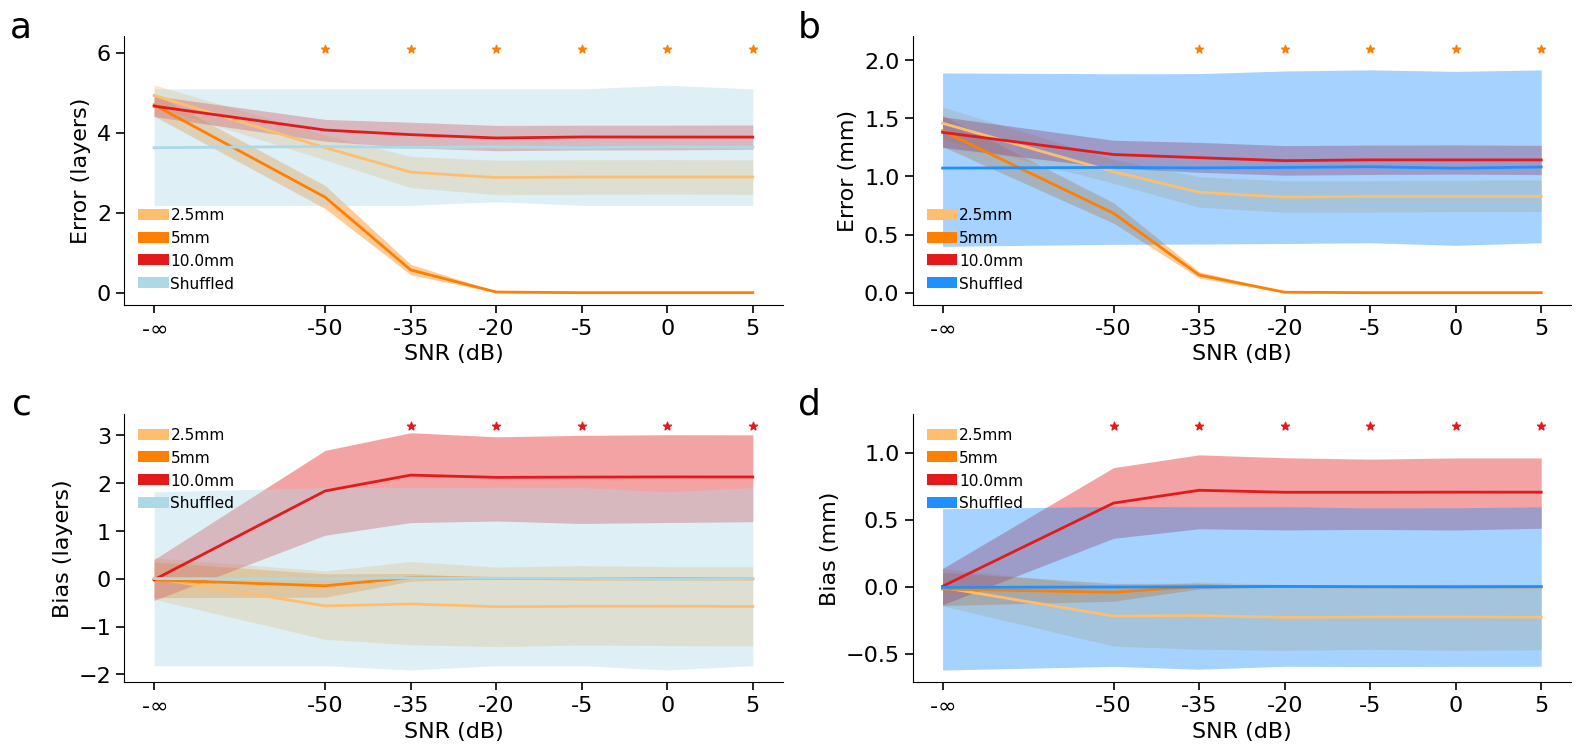

In [18]:
snrs_to_plot=[-500, -50, -35, -20]
fig=plt.figure(figsize=(4*len(snrs_to_plot), 14), facecolor="white")
gs = GridSpec(4, len(snrs_to_plot), height_ratios=[1, 1, 1.25, 1.25])

patch_size_clrs=np.array([[253,191,111],
                         [255,127,0],
                         [227,26,28]])/255
ax=fig.add_subplot(gs[2,0:2])
legend_handles = []
clrs = []
labs = []
for p_idx, patch_size in enumerate(patch_sizes):
    legend_handles.append(Patch(facecolor=patch_size_clrs[p_idx,:], linewidth=0, label=f"{patch_size}mm"))
    clrs.append(patch_size_clrs[p_idx,:])
    labs.append(f"{patch_size}mm")
legend_handles.append(Patch(facecolor="lightblue", linewidth=0, label="Shuffled"))
clrs.append("lightblue")
labs.append("shuffled data")
for p_idx, patch_size in enumerate(patch_sizes):
    ax.plot(snr_ix, error_res[patch_size][:,0], color=clrs[p_idx], lw=2)
    ax.fill_between(snr_ix, error_res[patch_size][:,1], error_res[patch_size][:,2], color=clrs[p_idx], lw=0, alpha=0.4)
ax.plot(snr_ix, shuf_error_res[5][:,0], color=clrs[len(patch_sizes)], lw=2)
ax.fill_between(snr_ix, shuf_error_res[5][:,1], shuf_error_res[5][:,2], color=clrs[len(patch_sizes)], lw=0, alpha=0.4)
ax.set_xticks(snr_ix)
ax.set_xticklabels(tick_labels)
ax.set_ylabel("Error (layers)")
ax.set_xlabel("SNR (dB)")
ax.legend(handles=legend_handles, fontsize="x-small", loc='lower left')
for p_idx, patch_size in enumerate(patch_sizes):
    sig_levels=np.where(p_values_error[patch_size]<0.05)[0]
    ax.scatter(snr_ix[sig_levels],np.tile(6+p_idx*.1,len(sig_levels)),marker='*',color=patch_size_clrs[p_idx,:])
add_subplot_label(ax, 'a', x=-.14, y=1.1)


ax=fig.add_subplot(gs[2,2:4])
legend_handles = []
clrs = []
labs = []
for p_idx, patch_size in enumerate(patch_sizes):
    legend_handles.append(Patch(facecolor=patch_size_clrs[p_idx,:], linewidth=0, label=f"{patch_size}mm"))
    clrs.append(patch_size_clrs[p_idx,:])
    labs.append(f"{patch_size}mm")
legend_handles.append(Patch(facecolor="dodgerblue", linewidth=0, label="Shuffled"))
clrs.append("dodgerblue")
labs.append("shuffled data")
for p_idx, patch_size in enumerate(patch_sizes):
    ax.plot(snr_ix, error_res_mm[patch_size][:,0], color=clrs[p_idx], lw=2)
    ax.fill_between(snr_ix, error_res_mm[patch_size][:,1], error_res_mm[patch_size][:,2], color=clrs[p_idx], lw=0, alpha=0.4)
ax.plot(snr_ix, shuf_error_res_mm[5][:,0], color=clrs[len(patch_sizes)], lw=2)
ax.fill_between(snr_ix, shuf_error_res_mm[5][:,1], shuf_error_res_mm[5][:,2], color=clrs[len(patch_sizes)], lw=0, alpha=0.4)
ax.set_xticks(snr_ix)
ax.set_xticklabels(tick_labels)
ax.set_ylabel("Error (mm)")
ax.set_xlabel("SNR (dB)")
ax.legend(handles=legend_handles, fontsize="x-small", loc='lower left')
for p_idx, patch_size in enumerate(patch_sizes):
    sig_levels=np.where(p_values_error_mm[patch_size]<0.05)[0]
    ax.scatter(snr_ix[sig_levels],np.tile(2+p_idx*.1,len(sig_levels)),marker='*',color=patch_size_clrs[p_idx,:])
add_subplot_label(ax, 'b', x=-.14, y=1.1)


ax=fig.add_subplot(gs[3,0:2])
legend_handles = []
clrs = []
labs = []
for p_idx, patch_size in enumerate(patch_sizes):
    legend_handles.append(Patch(facecolor=patch_size_clrs[p_idx,:], linewidth=0, label=f"{patch_size}mm"))
    clrs.append(patch_size_clrs[p_idx,:])
    labs.append(f"{patch_size}mm")
legend_handles.append(Patch(facecolor="lightblue", linewidth=0, label="Shuffled"))
clrs.append("lightblue")
labs.append("shuffled data")
for p_idx, patch_size in enumerate(patch_sizes):
    ax.plot(snr_ix, bias_res[patch_size][:,0], color=clrs[p_idx], lw=2)
    ax.fill_between(snr_ix, bias_res[patch_size][:,1], bias_res[patch_size][:,2], color=clrs[p_idx], lw=0, alpha=0.4)
ax.plot(snr_ix, shuf_bias_res[5][:,0], color=clrs[len(patch_sizes)], lw=2)
ax.fill_between(snr_ix, shuf_bias_res[5][:,1], shuf_bias_res[5][:,2], color=clrs[len(patch_sizes)], lw=0, alpha=0.4)
ax.set_xticks(snr_ix)
ax.set_xticklabels(tick_labels)
ax.set_ylabel("Bias (layers)")
ax.set_xlabel("SNR (dB)")
ax.legend(handles=legend_handles, fontsize="x-small", loc='upper left')
for p_idx, patch_size in enumerate(patch_sizes):
    sig_levels=np.where(p_values_bias[patch_size]<0.05)[0]
    ax.scatter(snr_ix[sig_levels],np.tile(3+p_idx*.1,len(sig_levels)),marker='*',color=patch_size_clrs[p_idx,:])
add_subplot_label(ax, 'c', x=-.14, y=1.1)


ax=fig.add_subplot(gs[3,2:4])
legend_handles = []
clrs = []
labs = []
for p_idx, patch_size in enumerate(patch_sizes):
    legend_handles.append(Patch(facecolor=patch_size_clrs[p_idx,:], linewidth=0, label=f"{patch_size}mm"))
    clrs.append(patch_size_clrs[p_idx,:])
    labs.append(f"{patch_size}mm")
legend_handles.append(Patch(facecolor="dodgerblue", linewidth=0, label="Shuffled"))
clrs.append("dodgerblue")
labs.append("shuffled data")
for p_idx, patch_size in enumerate(patch_sizes):
    ax.plot(snr_ix, bias_res_mm[patch_size][:,0], color=clrs[p_idx], lw=2)
    ax.fill_between(snr_ix, bias_res_mm[patch_size][:,1], bias_res_mm[patch_size][:,2], color=clrs[p_idx], lw=0, alpha=0.4)
ax.plot(snr_ix, shuf_bias_res_mm[5][:,0], color=clrs[len(patch_sizes)], lw=2)
ax.fill_between(snr_ix, shuf_bias_res_mm[5][:,1], shuf_bias_res_mm[5][:,2], color=clrs[len(patch_sizes)], lw=0, alpha=0.4)
ax.set_xticks(snr_ix)
ax.set_xticklabels(tick_labels)
ax.set_ylabel("Bias (mm)")
ax.set_xlabel("SNR (dB)")
ax.legend(handles=legend_handles, fontsize="x-small", loc='upper left')
for p_idx, patch_size in enumerate(patch_sizes):
    sig_levels=np.where(p_values_bias_mm[patch_size]<0.05)[0]
    ax.scatter(snr_ix[sig_levels],np.tile(1+p_idx*.1,len(sig_levels)),marker='*',color=patch_size_clrs[p_idx,:])
add_subplot_label(ax, 'd', x=-.14, y=1.1)

plt.tight_layout()
plt.savefig(f"figure_S5_snr_patch_size.pdf")